In [17]:
# import packages 
import pandas as pd 
import numpy as np 
import mlflow
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials


import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree

from scipy import stats
import statsmodels.api as sm

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc


## What you will find in this notebook: 

- ML Models to train this data
    2. Decision Tree 
    3. Random Forest 
    4. AdaBoost 
    
- An intuitive and mathematical explanation of each of these models. 

In [18]:
# read csv file 

heart_df = pd.read_csv("../data/cardio_train.csv", delimiter =";")

heart_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [19]:
heart_df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [20]:
categorical_col = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


heart_df[categorical_col] = heart_df[categorical_col].astype('category')
heart_df.dtypes

id                int64
age               int64
gender            int64
height            int64
weight          float64
ap_hi             int64
ap_lo             int64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio         category
dtype: object

#### There is no missing data, refer to analysis.ipynb

## Fix Data 

In [21]:
average_days_per_year = 365.25

heart_df['age'] = (heart_df['age']/ average_days_per_year).round().astype(int)

heart_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [22]:
heart_df["bmi"] = (heart_df["weight"]/((heart_df["height"]/100) **2)).round(2)

heart_df.pop('id')
heart_df.pop('height')
heart_df.pop('weight')

heart_df

,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,50,2,110,80,1,1,0,0,1,0,21.97
1,55,1,140,90,3,1,0,0,1,1,34.93
2,52,1,130,70,3,1,0,0,0,1,23.51
3,48,2,150,100,1,1,0,0,1,1,28.71
4,48,1,100,60,1,1,0,0,0,0,23.01
...,...,...,...,...,...,...,...,...,...,...,...
69995,53,2,120,80,1,1,1,0,1,0,26.93
69996,62,1,140,90,2,2,0,0,1,1,50.47
69997,52,2,180,90,3,1,0,1,0,1,31.35
69998,61,1,135,80,1,2,0,0,0,1,27.10


In [23]:
heart_df= heart_df[["age",
                    "gender",
                    "bmi",
                    "ap_hi",
                    "ap_lo",
                    "cholesterol",
                    "gluc",
                    "smoke",
                    "alco",
                    "active",
                    "cardio"]]
heart_df

,age,gender,bmi,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,21.97,110,80,1,1,0,0,1,0
1,55,1,34.93,140,90,3,1,0,0,1,1
2,52,1,23.51,130,70,3,1,0,0,0,1
3,48,2,28.71,150,100,1,1,0,0,1,1
4,48,1,23.01,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69995,53,2,26.93,120,80,1,1,1,0,1,0
69996,62,1,50.47,140,90,2,2,0,0,1,1
69997,52,2,31.35,180,90,3,1,0,1,0,1
69998,61,1,27.10,135,80,1,2,0,0,0,1


## Set MLFlow 

In [24]:
mlflow.__version__

'2.15.1'

In [25]:
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('cardio_disease')

<Experiment: artifact_location='/Users/bera/Desktop/MSDS/603/mlops/experiments/cardio_disease/mlruns/1', creation_time=1742880844134, experiment_id='1', last_update_time=1742880844134, lifecycle_stage='active', name='cardio_disease', tags={}>

## Setup the model 

In [26]:
y = heart_df["cardio"]
X = heart_df.drop(columns=["cardio"])


In [32]:
def train_val_test(X, y):
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, train_size=0.7, random_state=12, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.15, random_state=12, stratify=y_train_full
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = train_val_test(X, y)


In [33]:
# Check how stratified the data is. 
print(f"Y Train Data:\n{pd.Series(y_train).value_counts()/y_train.shape}")
print(f"\nY Test Data:\n{pd.Series(y_test).value_counts()/y_test.shape}")


Y Train Data:
cardio
0    0.500312
1    0.499688
Name: count, dtype: float64

Y Test Data:
cardio
0    0.500286
1    0.499714
Name: count, dtype: float64


## Define the models 

In [ ]:
pram_grid_dt 

In [177]:
best_params = random_search.best_params_
best_params

{'min_samples_split': 19,
 'min_samples_leaf': 9,
 'max_features': 0.3,
 'max_depth': 5}

In [178]:
best_score = random_search.best_score_
best_score

0.7215102040816327

In [179]:
final_model = DecisionTreeClassifier(**best_params)
final_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, max_features=0.3, min_samples_leaf=9,
                       min_samples_split=19)

In [180]:
y_pred = final_model.predict(X_test)
y_pred

array([1, 0, 0, ..., 1, 0, 1])

In [181]:
f1 = f1_score(y_test, y_pred)
f1

0.6746902654867256

In [182]:
y_proba = final_model.predict_proba(X_test)[:,1]
y_proba

array([0.51837441, 0.46562033, 0.34596627, ..., 0.8472381 , 0.16439976,
       0.51837441])

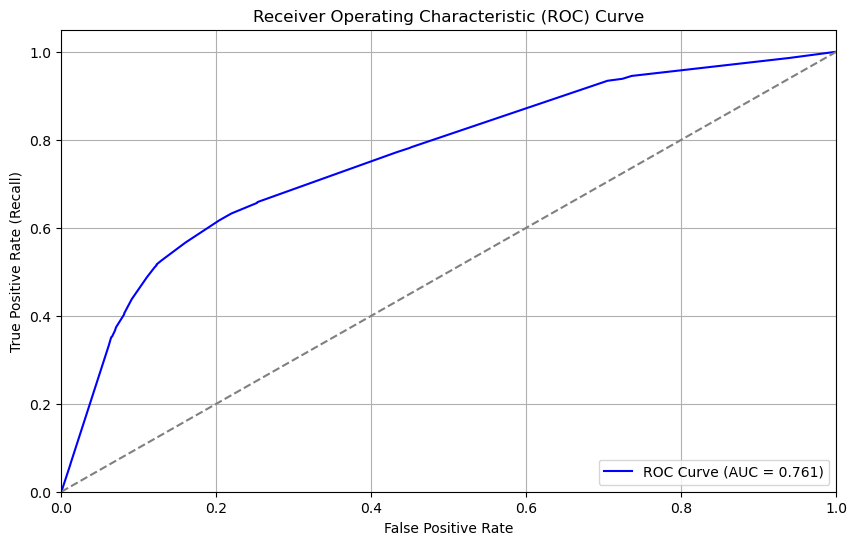

In [183]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

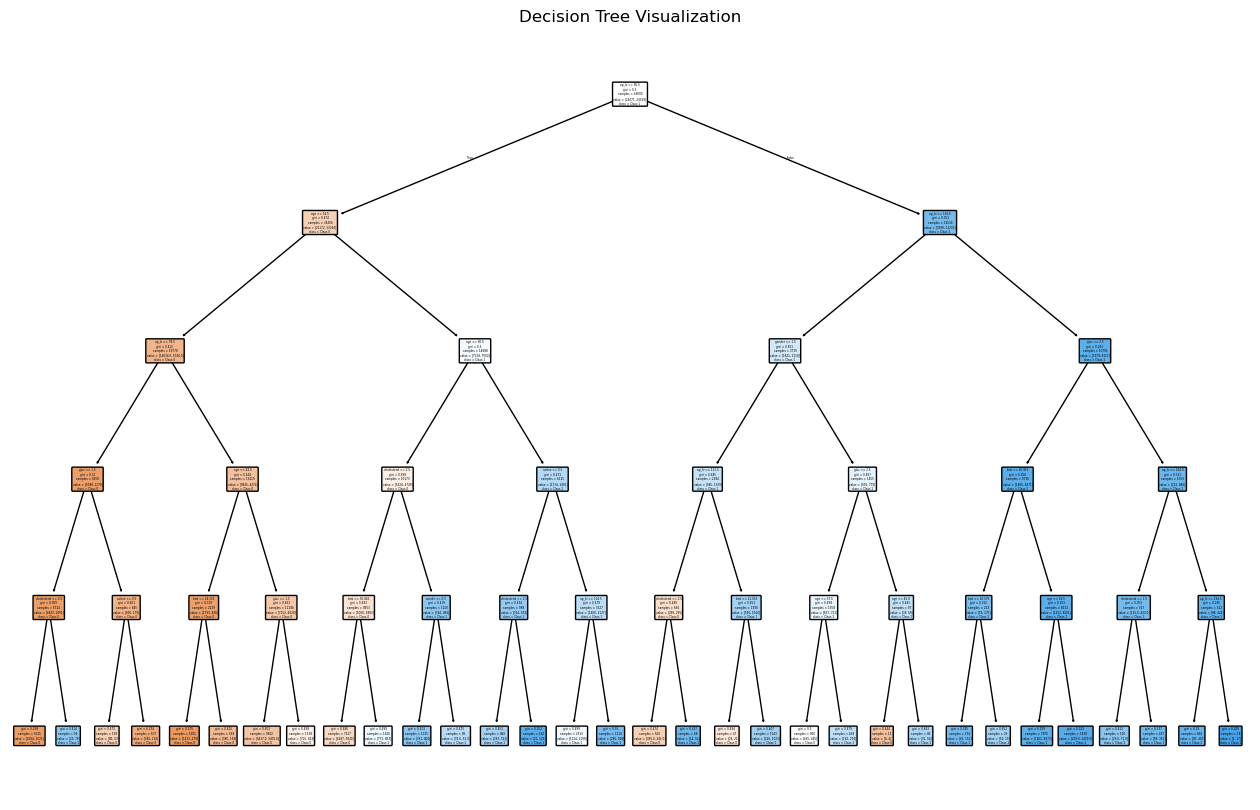

In [184]:
plt.figure(figsize=(16, 10))

plot_tree(final_model, feature_names=X_train.columns, class_names=['Class 0', 'Class 1'], filled=True, rounded=True)

plt.title("Decision Tree Visualization")
plt.show()

/var/folders/50/7ys27s856cj0_7svprhcb3580000gp/T/ipykernel_95102/3339064266.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



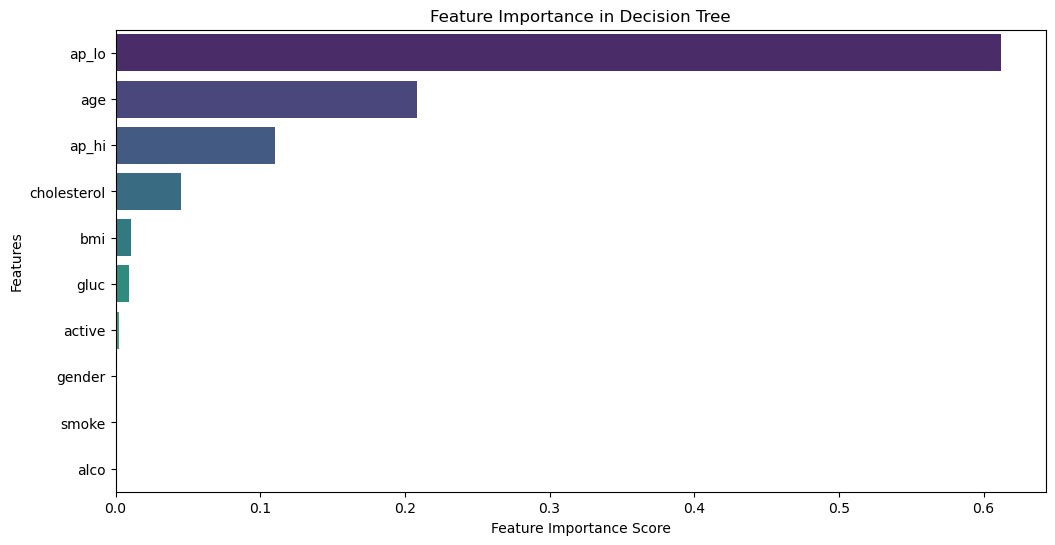

In [185]:
feature_importance = pd.Series(final_model.feature_importances_, index=X_train.columns)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance, y=feature_importance.index, palette="viridis")

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Decision Tree")
plt.show()